In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [18]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f3 only
function_folder = os.path.join(base_dir, "function_3")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f3 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 3: shape = {df_f3.shape}, columns = {df_f3.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']


In [19]:
week1_results = {"f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328)}

In [20]:
week2_results = {"f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705)}

In [21]:
week3_results = {"f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815)}

In [22]:
week4_results = {"f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105)}

In [23]:
week5_results = {"f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209)}

In [24]:
week6_results = {"f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577)}

In [25]:
week7_results = {"f3": ([0.110343, 0.915465, 0.655916], -0.12413097550625916)}

In [26]:
week8_results = {"f3": ([0.394618, 0.003779, 0.001514], -0.18116078744677863)}

In [27]:
week9_results = {"f3": ([0.905262, 0.964713, 0.000892], -0.13042760699767658)}

In [28]:
week10_results = {"f3": ([0.964677, 0.666640, 0.326523], -0.045607638959566356)}

In [29]:
week11_results = {"f3": ([0.633299, 0.771444, 0.514197], -0.027528304452980934)}

In [30]:
week12_results = {"f3": ([0.697350, 0.842980, 0.459360], -0.025630428429041174)}

In [31]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y3"

# add weekly results to df_f3

for week, results in weekly_results.items():
    
    if "f3" not in results:
        continue
    
    inputs, output = results["f3"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f3
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "y1"]
    )
    
    # append to df_f3
    df_f3 = pd.concat([df_f3, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f3 = df_f3.drop_duplicates(ignore_index=True)

print("updated f3 shape:", df_f3.shape)


updated f3 shape: (27, 4)


In [32]:
print(df_f3)

          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375
21  0.110343  0.915465  0.655916 -0.124131
22  0.39461

In [33]:
display(df_f3.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,27.0,0.499999,0.287466,0.046809,0.231332,0.492581,0.692801,0.967200
X2,27.0,0.566798,0.286799,0.003779,0.365000,0.644074,0.807212,0.964713
X3,27.0,0.411438,0.280766,0.000876,0.236298,0.343555,0.573505,0.990882
y1,27.0,-0.097433,0.076741,-0.398926,-0.115958,-0.094190,-0.043443,-0.025630


## Pearson Correlation

f3 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,y1
X1,1.000000,0.269764,-0.073483,0.200314
X2,0.269764,1.000000,-0.109943,0.331430
X3,-0.073483,-0.109943,1.000000,-0.252423
y1,0.200314,0.331430,-0.252423,1.000000


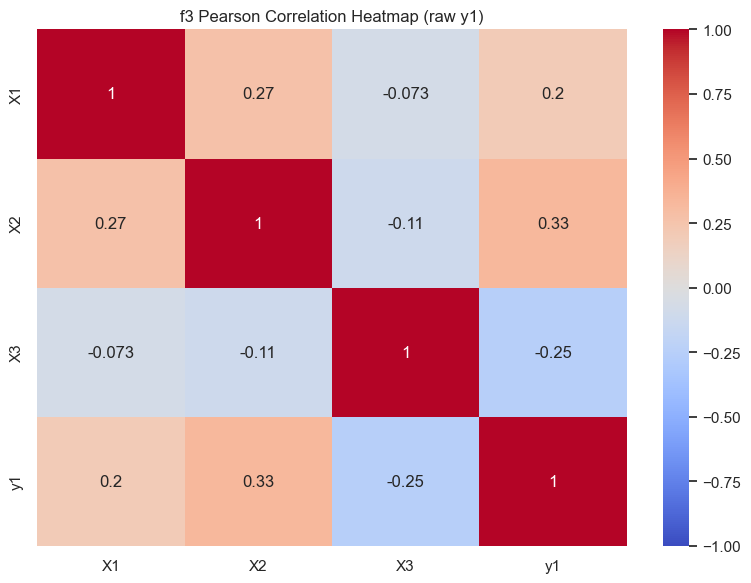

In [34]:
df_raw = df_f3.copy()

print("f3 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f3 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f3 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,y1
X1,1.000000,0.272894,-0.084249,0.147131
X2,0.272894,1.000000,-0.083639,0.305250
X3,-0.084249,-0.083639,1.000000,0.032967
y1,0.147131,0.305250,0.032967,1.000000


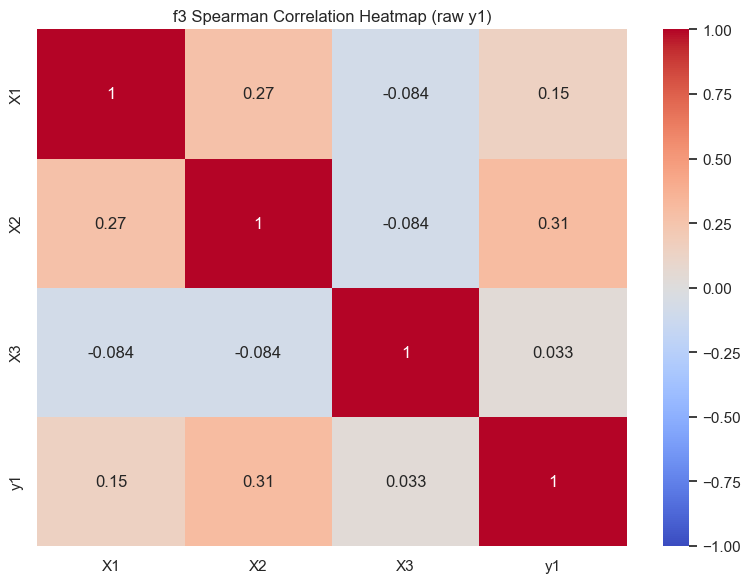

In [35]:
# spearman correlation with raw y1
df_raw = df_f3.copy()

print("f3 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f3 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information with Bootstrapped CI

In [36]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample


print("f3 — Mutual Information with Output (Bootstrap 50x)")

# extract X and y
df_f3_raw = df_f3.copy()
input_cols_f3 = [c for c in df_f3_raw.columns if c.startswith("X")]
output_col_f3 = "y1"

X_f3 = df_f3_raw[input_cols_f3].values
y_f3 = df_f3_raw[output_col_f3].values

# base MI estimate
mi_base = mutual_info_regression(X_f3, y_f3, n_neighbors=5, random_state=42)

# bootstrap MI
n_boot = 50
mi_boot = np.zeros((n_boot, len(input_cols_f3)))

for b in range(n_boot):
    Xb, yb = resample(X_f3, y_f3, replace=True, random_state=1000 + b)
    mi_boot[b] = mutual_info_regression(Xb, yb, n_neighbors=5, random_state=2000 + b)

# compute statistics
mi_mean = mi_boot.mean(axis=0)
mi_std = mi_boot.std(axis=0)
mi_se = mi_std / np.sqrt(n_boot)
mi_ci_low = mi_mean - 1.96 * mi_se
mi_ci_high = mi_mean + 1.96 * mi_se

# build dataframe
mi_df = pd.DataFrame({
    "Feature": input_cols_f3,
    "MI_base": mi_base,
    "MI_mean": mi_mean,
    "MI_std": mi_std,
    "MI_SE": mi_se,
    "CI_low": mi_ci_low,
    "CI_high": mi_ci_high
}).sort_values(by="MI_mean", ascending=False)

print("Mutual Information Summary (f3)")
print(mi_df.to_string(index=False))

# GTBO-style binary interpretation
print("Binary Interpretation (GTBO-style)")
for feat, mean, low in zip(mi_df["Feature"], mi_df["MI_mean"], mi_df["CI_low"]):
    if low > 0.01:
        status = "ACTIVE"
    else:
        status = "INACTIVE / NO EVIDENCE"
    print(f"{feat}: {status} (MI_mean={mean:.3f}, CI_low={low:.3f})")


f3 — Mutual Information with Output (Bootstrap 50x)
Mutual Information Summary (f3)
Feature  MI_base  MI_mean   MI_std    MI_SE   CI_low  CI_high
     X3 0.301934 0.333201 0.135006 0.019093 0.295779 0.370623
     X2 0.000000 0.119959 0.119679 0.016925 0.086786 0.153132
     X1 0.000000 0.071880 0.086810 0.012277 0.047817 0.095942
Binary Interpretation (GTBO-style)
X3: ACTIVE (MI_mean=0.333, CI_low=0.296)
X2: ACTIVE (MI_mean=0.120, CI_low=0.087)
X1: ACTIVE (MI_mean=0.072, CI_low=0.048)


## Pairwise scatter coloured by y rank


Feature vs y1 (raw) for f3


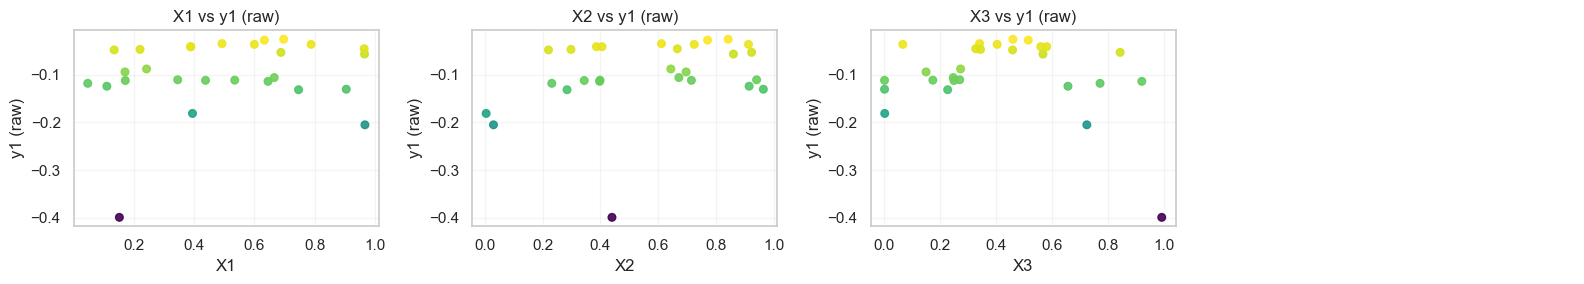

In [37]:
# === Feature vs raw y1 for f3 ===
print("\nFeature vs y1 (raw) for f3")

# extract inputs for f3
input_cols_f3 = [c for c in df_f3.columns if c.startswith("X")]
X_f3 = df_f3[input_cols_f3].values
y_f3 = df_f3["y1"].values

# number of input features
n_features = X_f3.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f3):
    ax = axes[j]
    sc = ax.scatter(
        X_f3[:, j],
        y_f3,
        c=y_f3,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Conditional Variance Analysis (X3 Binned)


X3 Conditional Variance Table for f3
   bin  x3_min  x3_max  n    mean_y     var_y     std_y     min_y     max_y
0    1     0.0     0.2  6 -0.110890  0.001859  0.043112 -0.181161 -0.036378
1    2     0.2     0.4  8 -0.084440  0.001189  0.034483 -0.131461 -0.034835
2    3     0.4     0.6  7 -0.039535  0.000103  0.010153 -0.056758 -0.025630
3    4     0.6     0.8  3 -0.149048  0.001570  0.039618 -0.204966 -0.118048
4    5     0.8     1.0  3 -0.188647  0.022723  0.150742 -0.398926 -0.053147


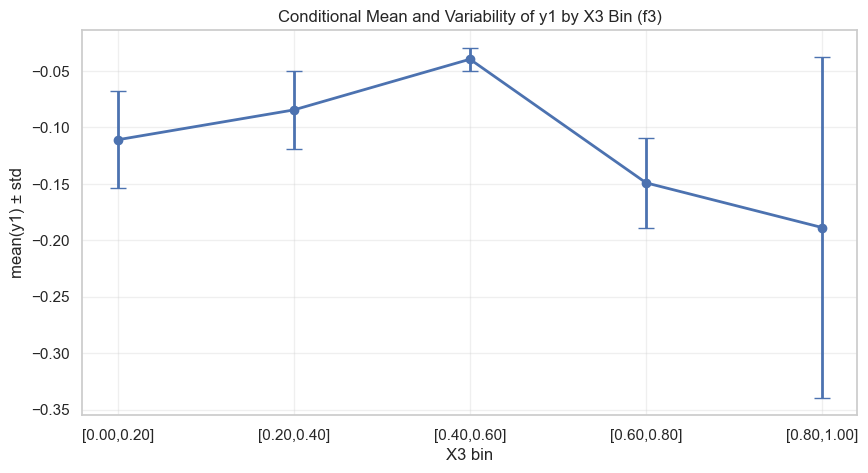

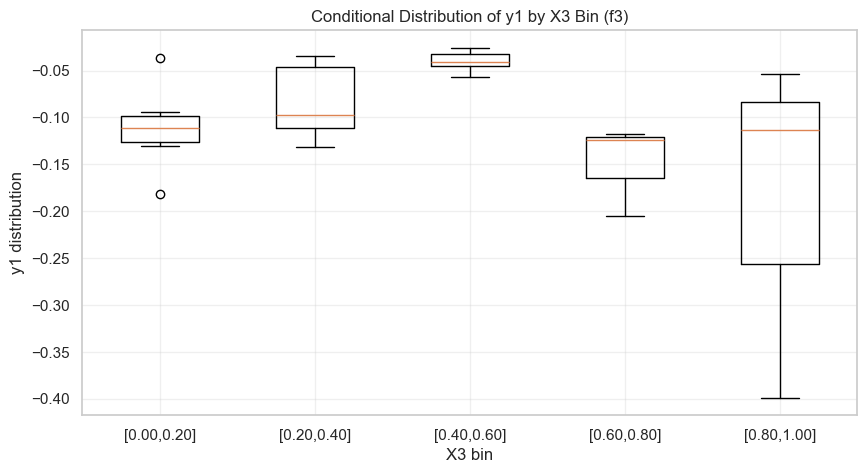

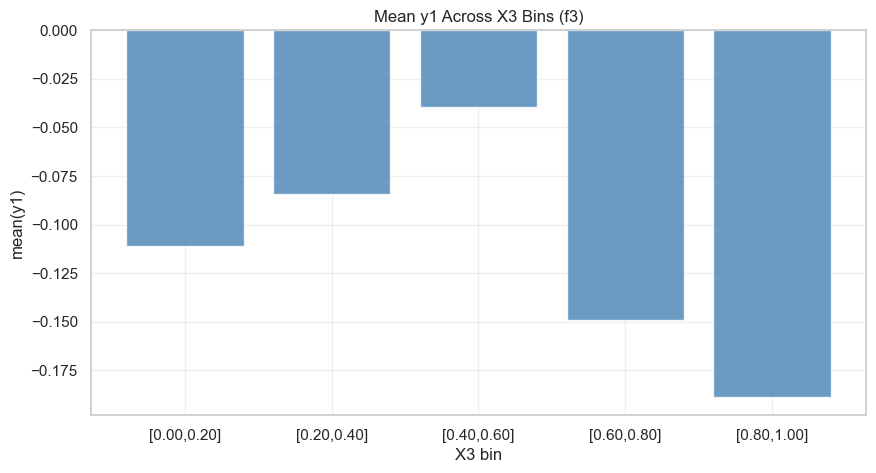

In [38]:
# extract X3 and y
x3 = df_f3["X3"].values.astype(float)
y  = df_f3["y1"].values.astype(float)

# define 5 equal-width bins from 0 to 1
bins = np.linspace(0, 1, 6)
bin_labels = np.digitize(x3, bins)

# collect diagnostics
rows = []
for b in range(1, 6):
    mask = bin_labels == b
    if mask.sum() > 0:
        rows.append({
            "bin": b,
            "x3_min": bins[b-1],
            "x3_max": bins[b],
            "n": mask.sum(),
            "mean_y": np.mean(y[mask]),
            "var_y": np.var(y[mask]),
            "std_y": np.std(y[mask]),
            "min_y": np.min(y[mask]),
            "max_y": np.max(y[mask])
        })

bin_df = pd.DataFrame(rows)
print("X3 Conditional Variance Table for f3")
print(bin_df)

# Visualization 1: Mean y with error bars 
plt.figure(figsize=(10,5))
plt.errorbar(
    x=bin_df["bin"],
    y=bin_df["mean_y"],
    yerr=bin_df["std_y"],
    fmt="o-", capsize=6, linewidth=2
)
plt.xticks(bin_df["bin"], [f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])])
plt.xlabel("X3 bin")
plt.ylabel("mean(y1) ± std")
plt.title("Conditional Mean and Variability of y1 by X3 Bin (f3)")
plt.grid(alpha=0.3)
plt.show()

# Visualization 2: Boxplot of y per X3 bin 
plt.figure(figsize=(10,5))
data = [y[bin_labels == b] for b in bin_df["bin"]]
plt.boxplot(data, labels=[f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])])
plt.xlabel("X3 bin")
plt.ylabel("y1 distribution")
plt.title("Conditional Distribution of y1 by X3 Bin (f3)")
plt.grid(alpha=0.3)
plt.show()

# Visualization 3: Bar plot of mean y 
plt.figure(figsize=(10,5))
plt.bar(
    [f"[{a:.2f},{b:.2f}]" for a,b in zip(bin_df["x3_min"], bin_df["x3_max"])],
    bin_df["mean_y"],
    color="steelblue",
    alpha=0.8
)
plt.xlabel("X3 bin")
plt.ylabel("mean(y1)")
plt.title("Mean y1 Across X3 Bins (f3)")
plt.grid(alpha=0.3)
plt.show()


## Sliced Inverse Regression (SIR)

SIR Hyperparameter Sweep Summary (f3)
   n_slices                                            eigvals  \
0         3  [0.24727844644578784, 0.03359755309942097, -1....   
1         4  [0.1419053766473435, 0.04199415583533759, 0.00...   
2         5  [0.30324313055116725, 0.0667952471616333, 0.01...   
3         6  [0.4530587657138234, 0.24778298071787497, 0.06...   
4         8  [0.5424667455609422, 0.09866032520145475, 0.06...   
5        10  [0.7568157005694758, 0.19791023682975958, 0.10...   
6        12  [0.8970431204797226, 0.34904820436355916, 0.10...   

   mean_angle_deg  std_angle_deg  quad_peak  cubic_peak  
0       74.724449      49.336123  -0.483027   -0.424182  
1       65.594192      48.268553  -0.619081   -0.703210  
2       67.669285      50.123092  -0.668385   -0.765926  
3      116.855736      46.553504   0.677121    0.535484  
4       79.150403      45.685277  -0.812570   -0.699226  
5       74.236926      55.675266  -0.488858   -0.187892  
6       63.710385      52.5

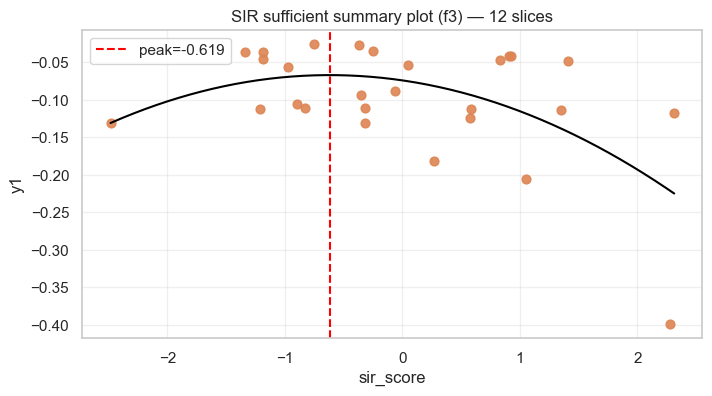

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# SIR implementation
def sliced_inverse_regression(X, y, n_slices=8):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape
    n_slices = max(2, min(n_slices, n))

    qs = np.linspace(0, 1, n_slices + 1)
    bins = np.quantile(y, qs)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)

    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    sir_dir = eigvecs[:, idx[0]]
    sir_dir /= np.linalg.norm(sir_dir) + 1e-12

    sir_scores = Xs @ sir_dir
    return sir_dir, sir_scores, scaler, eigvals[idx], eigvecs[:, idx]


# Bootstrap stability
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=125, random_state=0):
    rng = np.random.RandomState(random_state)
    angles = []

    base_dir, _, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            db, _, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            cosang = np.clip(
                np.dot(base_dir, db) /
                (np.linalg.norm(base_dir) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            ang = np.arccos(cosang)
            angles.append(ang)
        except:
            continue

    angles = np.array(angles)
    return np.degrees(np.nanmean(angles)), np.degrees(np.nanstd(angles))


# Peak extraction
def extract_peak(sir_scores, y, deg=2):
    coeffs = np.polyfit(sir_scores, y, deg=deg)
    if deg == 2:
        a, b, c = coeffs
        if abs(a) < 1e-12:
            return np.nan
        return -b / (2 * a)
    else:
        dcoeffs = np.polyder(coeffs)
        roots = np.roots(dcoeffs)
        roots = np.real(roots[np.isreal(roots)])
        valid = [r for r in roots if sir_scores.min() <= r <= sir_scores.max()]
        if len(valid) == 0:
            return np.nan
        return max(valid, key=lambda r: np.polyval(coeffs, r))


# Run sweep on df_f3
X = df_f3[[c for c in df_f3.columns if c.startswith("X")]].values.astype(float)
y = df_f3["y1"].values.astype(float)
input_cols = [c for c in df_f3.columns if c.startswith("X")]

slice_values = [3, 4, 5, 6, 8, 10, 12]
records = []
sir_results = {}

for n_slices in slice_values:
    sir_dir, sir_scores, scaler, eigvals, eigvecs = sliced_inverse_regression(X, y, n_slices=n_slices)

    mean_angle, std_angle = sir_bootstrap_stability(X, y, n_slices=n_slices)

    quad_peak = extract_peak(sir_scores, y, deg=2)
    cubic_peak = extract_peak(sir_scores, y, deg=3)

    records.append({
        "n_slices": n_slices,
        "eigvals": eigvals,
        "mean_angle_deg": mean_angle,
        "std_angle_deg": std_angle,
        "quad_peak": quad_peak,
        "cubic_peak": cubic_peak
    })

    sir_results[n_slices] = {
        "sir_scores": sir_scores,
        "sir_dir": sir_dir,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "quad_peak": quad_peak
    }


# Summary table
summary_df = pd.DataFrame(records)
print("SIR Hyperparameter Sweep Summary (f3)")
print(summary_df)


# Select slice count with lowest mean angle
best_row = summary_df.loc[summary_df["mean_angle_deg"].idxmin()]
best_slices = int(best_row["n_slices"])
print(f"\nMost stable slice count: {best_slices} slices (mean angle = {best_row['mean_angle_deg']:.2f}°)\n")


# Return full eigenvalues + full SIR direction
best = sir_results[best_slices]

print("Full Eigenvalues for Most Stable SIR (f3)")
print(best["eigvals"])

print("Full Leading SIR Direction (all inputs)")
for name, weight in zip(input_cols, best["sir_dir"]):
    print(f"{name}: {weight:.6f}")


# Plot only for the most stable slice count
sir_scores = best["sir_scores"]
quad_peak = best["quad_peak"]

plt.figure(figsize=(8,4))
plt.scatter(sir_scores, y, c="C1", s=40, alpha=0.9)
plt.xlabel("sir_score")
plt.ylabel("y1")
plt.title(f"SIR sufficient summary plot (f3) — {best_slices} slices")
plt.grid(alpha=0.3)

xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
qfit = np.polyval(np.polyfit(sir_scores, y, 2), xs)
plt.plot(xs, qfit, color="black", linewidth=1.5)

plt.axvline(quad_peak, color="red", linestyle="--", label=f"peak={quad_peak:.3f}")
plt.legend()

plt.show()



## Isomap Diagnostic + Near‑Best Neighbourhood Extraction

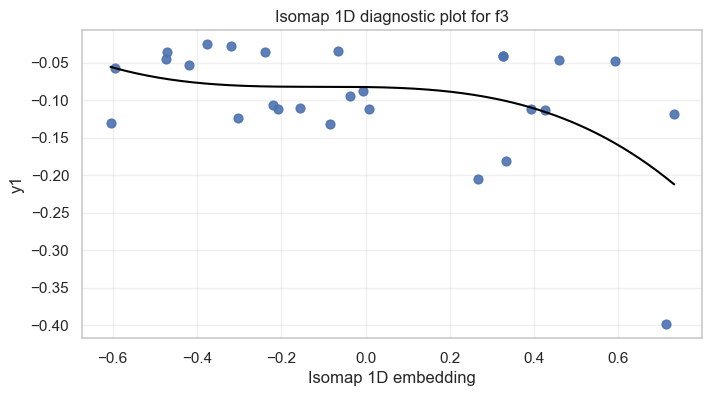

Near-Best Neighbourhood Summary (f3)
Feature  Centroid_Value
     X1        0.642344
     X2        0.772915
     X3        0.356582

Top-5 centroid (in X-space):
[0.64234394 0.77291518 0.35658241]
Neighbourhood radius: 0.2974

Interpretation:
- The top-5 observations cluster around the centroid above.
- The radius defines the actionable region for acquisition.
- This replaces the Isomap bonus: it is stable, local, and data-driven.


In [40]:
from sklearn.manifold import Isomap

# Load f3
df = df_f3.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
X = df[input_cols].values.astype(float)
y = df["y1"].values.astype(float)


# Isomap embedding (1D)
iso = Isomap(n_components=1, n_neighbors=5)
iso_scores = iso.fit_transform(X).flatten()

df["isomap_1d"] = iso_scores

# Visual diagnostic 
plt.figure(figsize=(8,4))
plt.scatter(iso_scores, y, c="C0", s=40, alpha=0.9)
plt.xlabel("Isomap 1D embedding")
plt.ylabel("y1")
plt.title("Isomap 1D diagnostic plot for f3")
plt.grid(alpha=0.3)

# smoothing curve
coeffs = np.polyfit(iso_scores, y, 3)
xs = np.linspace(iso_scores.min(), iso_scores.max(), 200)
ys = np.polyval(coeffs, xs)
plt.plot(xs, ys, color="black", linewidth=1.5)

plt.show()

# Near-best neighbourhood extraction

k = 5  # top-k points
df_sorted = df.sort_values("y1", ascending=False).reset_index(drop=True)
topk = df_sorted.iloc[:k]

# centroid in input space
centroid = topk[input_cols].mean().values

# radius = max distance from centroid to any top-k point
dists = np.linalg.norm(topk[input_cols].values - centroid, axis=1)
radius = dists.max()

# Summary table
summary = pd.DataFrame({
    "Feature": input_cols,
    "Centroid_Value": centroid
})

print("Near-Best Neighbourhood Summary (f3)")
print(summary.to_string(index=False))

print(f"\nTop-{k} centroid (in X-space):\n{centroid}")
print(f"Neighbourhood radius: {radius:.4f}")

print("\nInterpretation:")
print(f"- The top-{k} observations cluster around the centroid above.")
print("- The radius defines the actionable region for acquisition.")
print("- This replaces the Isomap bonus: it is stable, local, and data-driven.")


## Topological Data Analysis

In [41]:
from sklearn.cluster import DBSCAN
import numpy as np
import networkx as nx

def build_mapper_graph(X, filter_vals, n_intervals=4, overlap_frac=0.2,
                       cluster_eps=0.36, cluster_min_samples=1):

    n = len(filter_vals)
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_len = (fmax - fmin) / n_intervals
    overlap = interval_len * overlap_frac

    # define interval boundaries
    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_len - overlap
        end   = fmin + (i + 1) * interval_len + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0
    interval_nodes = []

    # clustering inside each interval
    for (start, end) in intervals:
        mask = (filter_vals >= start) & (filter_vals <= end)
        idx = np.where(mask)[0]

        if len(idx) == 0:
            interval_nodes.append([])
            continue

        X_sub = X[idx]

        # DBSCAN clustering
        db = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples)
        labels = db.fit_predict(X_sub)

        clusters = []
        for lab in np.unique(labels):
            if lab == -1:
                continue
            cluster_idx = idx[labels == lab]
            G.add_node(node_id, indices=cluster_idx, size=len(cluster_idx))
            clusters.append(node_id)
            node_id += 1

        interval_nodes.append(clusters)

    # connect clusters that share points
    for i in range(len(interval_nodes) - 1):
        for a in interval_nodes[i]:
            for b in interval_nodes[i + 1]:
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G


Mapper Summary for f3 (fixed parameters)
Nodes: 16
Edges: 8
Connected components: 8
Mean node size: 2.38
Interpretation: Multiple components → check for multi-basin structure.


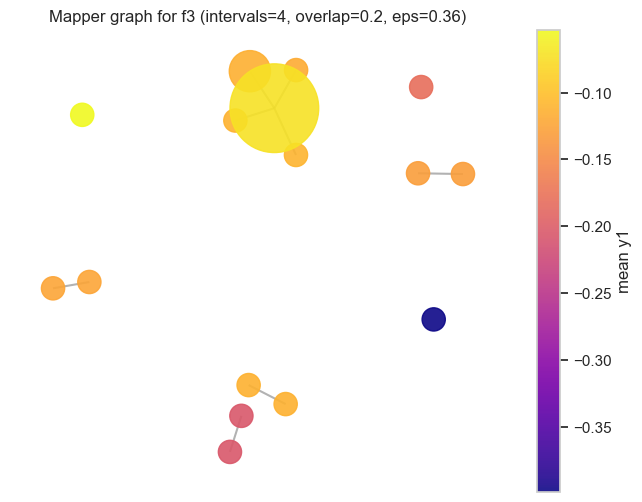

In [42]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# load f3
df = df_f3.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
X = df[input_cols].values.astype(float)
y = df["y1"].values.astype(float)

# fixed mapper parameters (best historically)
n_intervals = 4
overlap_frac = 0.20
eps = 0.36

# build mapper graph
G = build_mapper_graph(
    X,
    y,
    n_intervals=n_intervals,
    overlap_frac=overlap_frac,
    cluster_eps=eps,
    cluster_min_samples=1
)

# diagnostics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_components = nx.number_connected_components(G)
node_sizes = [G.nodes[n]["size"] for n in G.nodes]
mean_size = np.mean(node_sizes) if len(node_sizes) > 0 else 0

print("Mapper Summary for f3 (fixed parameters)")
print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Connected components: {num_components}")
print(f"Mean node size: {mean_size:.2f}")

if num_components == 1:
    print("Interpretation: Single connected component → single-basin structure confirmed.")
else:
    print("Interpretation: Multiple components → check for multi-basin structure.")

# visualization (optional)
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=0, k=0.4)

node_colors = [
    np.mean(y[G.nodes[n]["indices"]])
    for n in G.nodes
]

node_sizes = [
    80 + 200 * (G.nodes[n]["size"])
    for n in G.nodes
]

nodes = nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    cmap="plasma",
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color="gray")

plt.colorbar(nodes, label="mean y1")
plt.title(f"Mapper graph for f3 (intervals={n_intervals}, overlap={overlap_frac}, eps={eps})")
plt.axis("off")
plt.show()


## Pairwise distance matrix

In [43]:
from sklearn.metrics import pairwise_distances
import numpy as np

k = 10
df_sorted = df_f3.sort_values("y1", ascending=False).reset_index(drop=True)
topk = df_sorted.iloc[:k]

D = pairwise_distances(topk[[c for c in df_f3.columns if c.startswith("X")]])

print("Pairwise distances among top-k:")
print(np.round(D, 3))

# cluster test
threshold = np.percentile(D, 75)  # heuristic
components = (D < threshold).astype(int)

print("\nInterpretation:")
if (components.sum(axis=1) == k).all():
    print("Top-k points form one coherent cluster → single basin.")
else:
    print("Top-k points split into subclusters → possible multi-basin structure.")


Pairwise distances among top-k:
[[0.    0.111 0.331 0.128 0.422 0.56  0.55  0.347 0.733 0.84 ]
 [0.111 0.    0.275 0.238 0.452 0.458 0.446 0.395 0.651 0.746]
 [0.331 0.275 0.    0.427 0.316 0.331 0.333 0.475 0.415 0.544]
 [0.128 0.238 0.427 0.    0.43  0.679 0.671 0.313 0.84  0.955]
 [0.422 0.452 0.316 0.43  0.    0.634 0.642 0.452 0.635 0.791]
 [0.56  0.458 0.331 0.679 0.634 0.    0.029 0.681 0.287 0.32 ]
 [0.55  0.446 0.333 0.671 0.642 0.029 0.    0.682 0.309 0.337]
 [0.347 0.395 0.475 0.313 0.452 0.681 0.682 0.    0.831 0.952]
 [0.733 0.651 0.415 0.84  0.635 0.287 0.309 0.831 0.    0.163]
 [0.84  0.746 0.544 0.955 0.791 0.32  0.337 0.952 0.163 0.   ]]

Interpretation:
Top-k points split into subclusters → possible multi-basin structure.


## Distrbution Analysis

f3 raw – feature and output distributions


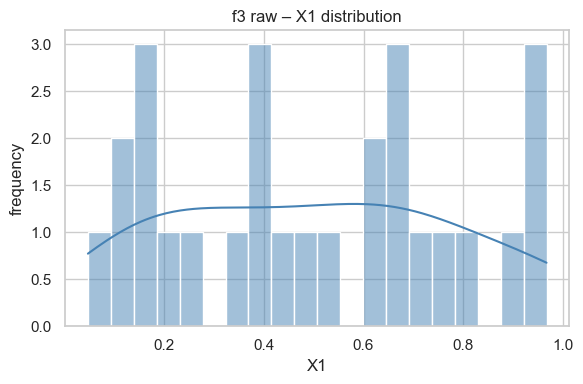

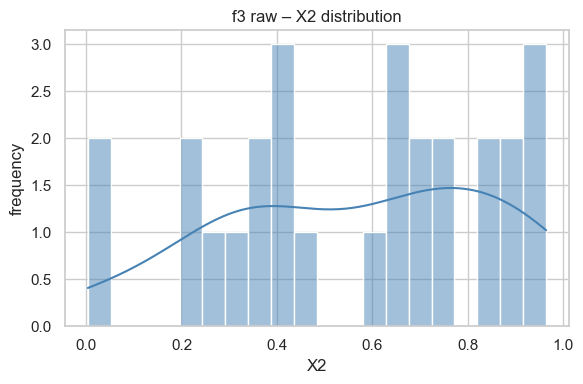

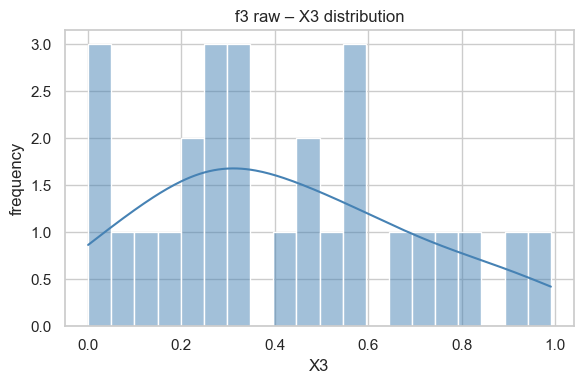

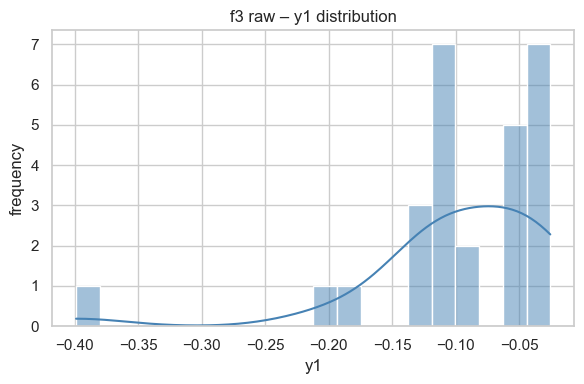

In [44]:
print("f3 raw – feature and output distributions")

# inputs for f3
input_cols_f3 = [c for c in df_f3.columns if c.startswith("X")]
output_col_f3 = "y1"

all_cols_raw_f3 = input_cols_f3 + [output_col_f3]

for col in all_cols_raw_f3:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f3[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f3 raw – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()


### Line Plot of y Values

f3 raw – y1 vs instance index


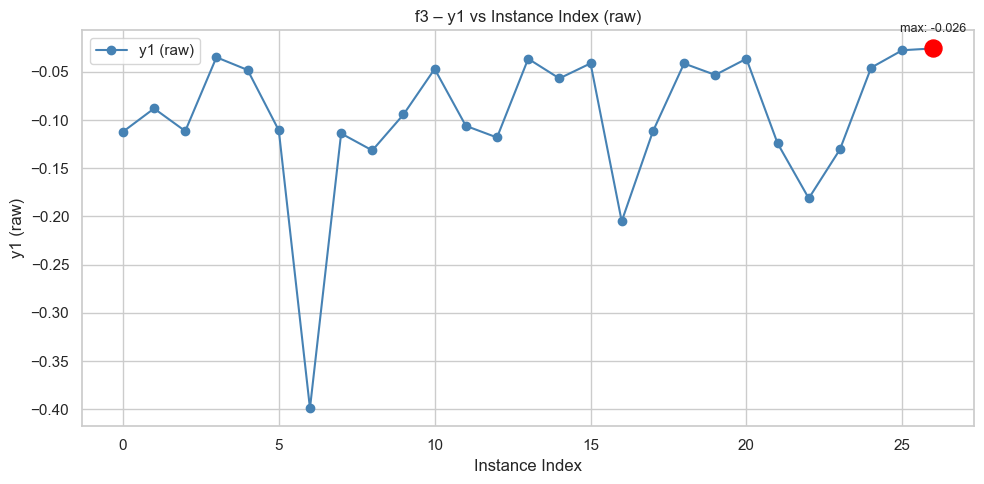

In [45]:
# 1. Create a clean copy of the RAW f3 data
df_f3_raw = df_f3.copy()

print("f3 raw – y1 vs instance index")

# 2. Extract raw y1
y_raw = df_f3_raw["y1"].values
x = np.arange(len(y_raw))

# 3. Plot
plt.figure(figsize=(10, 5))

plt.plot(
    x,
    y_raw,
    marker="o",
    linestyle="-",
    color="steelblue",
    label="y1 (raw)"
)

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f3 – y1 vs Instance Index (raw)")
plt.xlabel("Instance Index")
plt.ylabel("y1 (raw)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.manifold import Isomap

In [47]:
# Separate inputs (X) and outputs (y)
X_train_3 = df_f3[[c for c in df_f3.columns if c.startswith("X")]].values
y_train_3 = df_f3["y1"].values
print(X_train_3)
print(y_train_3)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [3.89233000e-01 3.86084000e-01 5.58916000e-01]
 [9.67200000e-01 2.92000000e-02 7.23300000e-01]
 [4.37962000e-01 7.15305000e-01 8.76000000e-04]
 [3.87933000e-01 4.05240000e-01 5.80181000e-01]
 [6.88252000e-01 9.24125000e-01 8.42251000e-01]
 [7.88392000e-01 9.13423000e-01 4.030900

## near-best neighbourhood analysis

In [48]:
# research basis: eriksson et al. (2019) turbo, neurips
#                 sim et al. (2025) gtbo, arxiv 2504.06111
# purpose: identify the centroid, radius, and per-dimension spread of the
#          top-k observations in f3. this is the small-n approximation of
#          turbo trust region centring and gtbo active dimension identification.
#          at n=25 it is more reliable than gp-ard because it requires no
#          surrogate fit and makes no smoothness assumptions.
# confirmed structural knowledge used here:
#          x1: mi=0 confirmed irrelevant across all weeks
#          x2: positive effect, active
#          x3: non-monotonic plateau in [0.06, 0.60]

def f3_near_best_neighbourhood(X_train_3, y_train_3, k=5):
    """
    compute the centroid, per-dimension std, and radius of the top-k
    observations for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3 with columns [x1, x2, x3]
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    k : int
        number of top observations to include in the neighbourhood

    returns
    -------
    dict with centroid, per_dim_std, radius, suggested_bounds, top_k_idx
    """
    n = len(y_train_3)
    feature_names = ["x1", "x2", "x3"]

    # sort by output descending to get top-k (maximisation)
    top_k_idx = np.argsort(y_train_3)[-k:][::-1]
    top_k_X = X_train_3[top_k_idx]
    top_k_y = y_train_3[top_k_idx]

    centroid = np.mean(top_k_X, axis=0)
    per_dim_std = np.std(top_k_X, axis=0)
    per_dim_min = np.min(top_k_X, axis=0)
    per_dim_max = np.max(top_k_X, axis=0)

    # radius: mean euclidean distance from centroid to each top-k point
    radius = np.mean(np.linalg.norm(top_k_X - centroid, axis=1))

    # tightest dimension: smallest std among top-k
    # for f3: x1 expected tightest (irrelevant so spreads randomly but
    # near-best observations happen to cluster in whatever x1 range was sampled)
    # x2 and x3 expected to show tighter clustering than full dataset
    tightest_dim = np.argmin(per_dim_std)
    loosest_dim = np.argmax(per_dim_std)

    print("f3 near-best neighbourhood analysis (top-{})".format(k))
    print("\ntop-{} observations:".format(k))
    print("  {:>5}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}".format(
        "rank", "y", "x1", "x2", "x3", "dist_centroid"))
    for rank, idx in enumerate(top_k_idx):
        dist = np.linalg.norm(X_train_3[idx] - centroid)
        print("  {:>5}  {:>8.5f}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>10.4f}".format(
            rank + 1,
            y_train_3[idx],
            X_train_3[idx, 0],
            X_train_3[idx, 1],
            X_train_3[idx, 2],
            dist))

    print("\ncentroid of top-{} neighbourhood:".format(k))
    for j, name in enumerate(feature_names):
        print("  {}: {:.4f}".format(name, centroid[j]))

    print("\nper-dimension spread within top-{} neighbourhood:".format(k))
    for j, name in enumerate(feature_names):
        print("  {}: std={:.4f}, range=[{:.4f}, {:.4f}]".format(
            name, per_dim_std[j], per_dim_min[j], per_dim_max[j]))

    print("\nneighbourhood radius (mean dist from centroid): {:.4f}".format(radius))
    print("tightest dimension (most constrained near best): {} (std={:.4f})".format(
        feature_names[tightest_dim], per_dim_std[tightest_dim]))
    print("loosest dimension (most variable near best): {} (std={:.4f})".format(
        feature_names[loosest_dim], per_dim_std[loosest_dim]))

    # x1 relevance check: if x1 std is not the largest it suggests
    # some x1 structure exists near the best -- would contradict mi=0
    x1_std = per_dim_std[0]
    x2_std = per_dim_std[1]
    x3_std = per_dim_std[2]
    print("\nx1 relevance check (mi=0 confirmed -- x1 std should be large):")
    if x1_std >= max(x2_std, x3_std):
        print("  x1 std={:.4f} is largest -- confirms x1 irrelevant near best".format(
            x1_std))
    else:
        print("  x1 std={:.4f} is not largest -- x1 may have local structure".format(
            x1_std))
        print("  this contradicts mi=0 -- monitor in future weeks")

    # suggested acquisition bounds: centroid +/- 1.5 * std per dimension
    # clipped to [0,1] and additionally clipped to confirmed structural bounds
    # x2: [0.35, 0.95] confirmed near-best range from eda history
    # x3: [0.06, 0.60] confirmed plateau range from eda history
    print("\nsuggested acquisition bounds (centroid +/- 1.5 * std):")
    bounds = []
    structural_lo = [0.0, 0.35, 0.06]
    structural_hi = [1.0, 0.95, 0.60]
    for j, name in enumerate(feature_names):
        lo = np.clip(centroid[j] - 1.5 * per_dim_std[j],
                     structural_lo[j], structural_hi[j])
        hi = np.clip(centroid[j] + 1.5 * per_dim_std[j],
                     structural_lo[j], structural_hi[j])
        bounds.append((lo, hi))
        print("  {}: [{:.4f}, {:.4f}]".format(name, lo, hi))

    print("\n  note: x1 bounds are free [0.0, 1.0] because mi=0 is confirmed")
    print("  note: x2 and x3 bounds are additionally clipped to structural")
    print("        constraints derived from 11 weeks of eda history")

    return {
        "top_k_idx": top_k_idx,
        "top_k_X": top_k_X,
        "top_k_y": top_k_y,
        "centroid": centroid,
        "per_dim_std": per_dim_std,
        "radius": radius,
        "tightest_dim": tightest_dim,
        "loosest_dim": loosest_dim,
        "suggested_bounds": bounds
    }
    
top_k = f3_near_best_neighbourhood(X_train_3, y_train_3, k=5)    

f3 near-best neighbourhood analysis (top-5)

top-5 observations:
   rank         y        x1        x2        x3  dist_centroid
      1  -0.02563    0.6974    0.8430    0.4594      0.1360
      2  -0.02753    0.6333    0.7714    0.5142      0.1579
      3  -0.03484    0.4926    0.6116    0.3402      0.2207
      4  -0.03637    0.7884    0.9134    0.4031      0.2079
      5  -0.03638    0.6001    0.7251    0.0661      0.2974

centroid of top-5 neighbourhood:
  x1: 0.6423
  x2: 0.7729
  x3: 0.3566

per-dimension spread within top-5 neighbourhood:
  x1: std=0.0986, range=[0.4926, 0.7884]
  x2: std=0.1029, range=[0.6116, 0.9134]
  x3: std=0.1563, range=[0.0661, 0.5142]

neighbourhood radius (mean dist from centroid): 0.2040
tightest dimension (most constrained near best): x1 (std=0.0986)
loosest dimension (most variable near best): x3 (std=0.1563)

x1 relevance check (mi=0 confirmed -- x1 std should be large):
  x1 std=0.0986 is not largest -- x1 may have local structure
  this contradicts

## LOO Residual Map

In [49]:
# research basis: duxiaoman team report, neurips 2020 bbo challenge
#                 vovk (2013) kernel ridge regression, empirical inference
# purpose: report per-observation loo prediction error for f3 using krr.
#          large loo residuals for near-best observations signal that the
#          surrogate has a blind spot in the peak region and should not be
#          used for pure mean exploitation.
#          small loo residuals for near-best observations are the only valid
#          justification for exploitation-focused acquisition.
# critical lesson from f3 history: the neglog krr had mean near-best loo
#          residual of 0.031 but row 13 alone had error 0.079 -- the per-
#          observation table caught this; the mean statistic alone did not.

def f3_loo_residual_map(X_train_3, y_train_3, k_best=5,
                         alpha_grid=None, gamma_grid=None):
    """
    fit krr with loo-cv hp tuning and report per-observation loo residuals
    for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    k_best : int
        number of top observations for detailed residual reporting
    alpha_grid : list of float, optional
        krr regularisation values to search
    gamma_grid : list of float, optional
        krr rbf bandwidth values to search

    returns
    -------
    dict with loo_preds, loo_residuals, loo_rmse, surrogate_reliable,
         near_best_residuals, worst_rows
    """
    n = len(y_train_3)
    feature_names = ["x1", "x2", "x3"]

    if alpha_grid is None:
        alpha_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5]
    if gamma_grid is None:
        gamma_grid = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

    loo = LeaveOneOut()

    # loo-cv grid search for best krr hyperparameters
    # loo-cv is exact at small n and avoids train-test split variance
    best_mse = np.inf
    best_alpha, best_gamma = 0.01, 0.5
    best_loo_preds = None

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
            preds = np.zeros(n)
            for tr, val in loo.split(X_train_3):
                krr.fit(X_train_3[tr], y_train_3[tr])
                preds[val] = krr.predict(X_train_3[val])
            mse = mean_squared_error(y_train_3, preds)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_gamma = gamma
                best_loo_preds = preds.copy()

    loo_residuals = y_train_3 - best_loo_preds
    loo_abs_residuals = np.abs(loo_residuals)
    loo_mse = mean_squared_error(y_train_3, best_loo_preds)
    loo_rmse = np.sqrt(loo_mse)

    print("=== f3 loo residual map ===")
    print("\nkrr hyperparameters selected by loo-cv:")
    print("  alpha: {}, gamma: {}".format(best_alpha, best_gamma))
    print("  loo mse: {:.6f}".format(loo_mse))
    print("  loo rmse: {:.6f}".format(loo_rmse))
    print("  baseline loo rmse from week 11: 0.080937")
    improvement = 0.080937 - loo_rmse
    if improvement > 0:
        print("  improvement over baseline: {:.6f}".format(improvement))
    else:
        print("  regression from baseline: {:.6f}".format(-improvement))

    # full per-observation residual table sorted by actual output descending
    sort_by_y = np.argsort(y_train_3)[::-1]
    print("\nfull loo residual table for f3 (sorted by actual output descending):")
    print("  {:>5}  {:>10}  {:>10}  {:>10}  {:>10}  {:>10}".format(
        "row", "actual", "loo_pred", "residual", "abs_resid", "flag"))
    for idx in sort_by_y:
        rel = loo_abs_residuals[idx] / (loo_rmse + 1e-10)
        if rel < 0.5:
            flag = "ok"
        elif rel < 1.0:
            flag = "marginal"
        else:
            flag = "poor"
        print("  {:>5}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>10}".format(
            idx,
            y_train_3[idx],
            best_loo_preds[idx],
            loo_residuals[idx],
            loo_abs_residuals[idx],
            flag))

    # detailed focus on top-k observations
    # this is the critical table: if any top-k row is flagged poor,
    # the surrogate should not be used for exploitation near that row
    top_k_idx = np.argsort(y_train_3)[-k_best:][::-1]
    near_best_abs = loo_abs_residuals[top_k_idx]
    mean_near_best = np.mean(near_best_abs)
    max_near_best = np.max(near_best_abs)

    print("\ndetailed loo residuals for top-{} observations:".format(k_best))
    print("  {:>5}  {:>10}  {:>10}  {:>10}  {:>8}  {}".format(
        "row", "actual", "loo_pred", "abs_error", "rel_rmse", "reliability"))
    any_catastrophic = False
    catastrophic_rows = []
    for rank, idx in enumerate(top_k_idx):
        rel = loo_abs_residuals[idx] / (loo_rmse + 1e-10)
        if rel < 0.5:
            flag = "reliable"
        elif rel < 1.0:
            flag = "marginal"
        elif rel < 2.0:
            flag = "poor"
        else:
            flag = "catastrophic"
            any_catastrophic = True
            catastrophic_rows.append(idx)
        print("  {:>5}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>8.3f}  {}".format(
            idx,
            y_train_3[idx],
            best_loo_preds[idx],
            loo_abs_residuals[idx],
            rel,
            flag))

    print("\nmean abs loo residual in top-{} region: {:.6f}".format(
        k_best, mean_near_best))
    print("max abs loo residual in top-{} region: {:.6f}".format(
        k_best, max_near_best))

    # catastrophic failure check
    # this caught the row 13 failure in the neglog krr experiment
    # a single catastrophic row in the top-k is sufficient to make the
    # surrogate unreliable for exploitation even if the mean residual looks ok
    if any_catastrophic:
        print("\ncatastrophic loo failure detected in top-k:")
        for idx in catastrophic_rows:
            print("  row {}: actual={:.5f}, loo_pred={:.5f}, "
                  "error={:.5f} ({:.1f}x rmse)".format(
                idx,
                y_train_3[idx],
                best_loo_preds[idx],
                loo_abs_residuals[idx],
                loo_abs_residuals[idx] / (loo_rmse + 1e-10)))
        print("  these rows are structurally isolated -- surrogate cannot")
        print("  recover their values from neighbours in loo")
        print("  exploitation near these rows is unreliable despite low mean residual")

    # surrogate reliability decision
    # two-gate system:
    # gate 1: mean near-best residual < 50% of loo rmse
    # gate 2: no catastrophic individual failure in top-k
    gate_1 = mean_near_best < 0.5 * loo_rmse
    gate_2 = not any_catastrophic
    surrogate_reliable = gate_1 and gate_2

    print("\nsurrogate reliability assessment:")
    print("  gate 1 (mean near-best < 0.5 * rmse): {}".format(
        "pass" if gate_1 else "fail"))
    print("  gate 2 (no catastrophic top-k failure): {}".format(
        "pass" if gate_2 else "fail"))
    if surrogate_reliable:
        print("  verdict: reliable -- exploitation acquisition is justified")
    else:
        print("  verdict: not reliable -- use structural constraints only")
        print("  recommended action: submit deterministic gap fill or")
        print("  near-best neighbourhood candidate without surrogate scoring")

    # identify confirmed outlier rows: rows 6, 16, 22
    # these are the structural outliers identified across all 11 weeks
    confirmed_outliers = [6, 16, 22]
    print("\nconfirmed structural outlier diagnostics (rows 6, 16, 22):")
    for idx in confirmed_outliers:
        if idx < n:
            print("  row {}: actual={:.5f}, loo_pred={:.5f}, "
                  "error={:.5f}".format(
                idx,
                y_train_3[idx],
                best_loo_preds[idx],
                loo_abs_residuals[idx]))
    print("  these rows should have large loo errors -- the surrogate")
    print("  cannot fit them well because they are geometrically isolated")
    print("  in x3 space (x3=0.991, x3=0.723, x3=0.002)")

    # three worst-predicted rows
    worst_3_idx = np.argsort(loo_abs_residuals)[-3:][::-1]
    print("\nthree worst-predicted rows overall:")
    for idx in worst_3_idx:
        in_top_k = idx in top_k_idx
        print("  row {}: error={:.5f}{}".format(
            idx,
            loo_abs_residuals[idx],
            " -- WARNING: this is a near-best observation" if in_top_k else ""))

    return {
        "best_alpha": best_alpha,
        "best_gamma": best_gamma,
        "loo_preds": best_loo_preds,
        "loo_residuals": loo_residuals,
        "loo_abs_residuals": loo_abs_residuals,
        "loo_mse": loo_mse,
        "loo_rmse": loo_rmse,
        "top_k_idx": top_k_idx,
        "near_best_abs_residuals": near_best_abs,
        "mean_near_best_residual": mean_near_best,
        "max_near_best_residual": max_near_best,
        "surrogate_reliable": surrogate_reliable,
        "gate_1": gate_1,
        "gate_2": gate_2,
        "catastrophic_rows": catastrophic_rows,
        "worst_3_idx": worst_3_idx
    }

best_alpha = f3_loo_residual_map(X_train_3, y_train_3, k_best=5,
                         alpha_grid=None, gamma_grid=None)

=== f3 loo residual map ===

krr hyperparameters selected by loo-cv:
  alpha: 0.01, gamma: 0.5
  loo mse: 0.005900
  loo rmse: 0.076810
  baseline loo rmse from week 11: 0.080937
  improvement over baseline: 0.004127

full loo residual table for f3 (sorted by actual output descending):
    row      actual    loo_pred    residual   abs_resid        flag
     26    -0.02563    -0.03058     0.00495     0.00495          ok
     25    -0.02753    -0.03276     0.00523     0.00523          ok
      3    -0.03484    -0.05017     0.01533     0.01533          ok
     20    -0.03637    -0.03441    -0.00197     0.00197          ok
     13    -0.03638    -0.11596     0.07959     0.07959        poor
     15    -0.04117    -0.07174     0.03057     0.03057          ok
     18    -0.04128    -0.07582     0.03454     0.03454          ok
     24    -0.04561    -0.09337     0.04777     0.04777    marginal
     10    -0.04695    -0.06424     0.01729     0.01729          ok
      4    -0.04801    -0.06954  

## fanova feature importance

In [50]:
from sklearn.ensemble import RandomForestRegressor
# research basis: sim et al. (2025) gtbo, arxiv 2504.06111, figure 6
#                 hutter et al. (2014) fanova for hp importance, icml
# purpose: decompose f3 output variance into main effects (x1, x2, x3) and
#          pairwise interactions (x1*x2, x1*x3, x2*x3).
#          for f3 the expected result based on 11 weeks of evidence is:
#          - x1 main effect: near zero (mi=0 confirmed)
#          - x2 main effect: moderate (pearson 0.286 confirmed)
#          - x3 main effect: moderate but non-monotonic
#          - x2*x3 interaction: significant (blr found coefficient 0.096)
#          if fanova finds x2*x3 interaction > 10% of total variance it
#          confirms that joint x2-x3 optimisation is required -- not
#          dimension-by-dimension search

def f3_fanova(X_train_3, y_train_3, n_estimators=500,
               n_grid=20, random_state=42):
    """
    compute fanova main effects and pairwise interactions for f3.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3)
        input observations for f3
    y_train_3 : ndarray of shape (n,)
        output observations for f3
    n_estimators : int
        number of trees in the random forest surrogate
    n_grid : int
        grid resolution for marginalisation (n_grid^2 evaluations per pair)
    random_state : int
        random seed for reproducibility

    returns
    -------
    dict with main_effects, interactions, separability_score, ranked_effects
    """
    feature_names = ["x1", "x2", "x3"]
    d = 3

    # fit random forest surrogate on f3 data
    # random forests are used by gtbo (figure 6) for fanova because they
    # capture non-linear and non-monotonic effects without kernel assumptions
    # for f3 this is essential because x3 has a non-monotonic plateau shape
    # that rbf kernels struggle to represent at n=25
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=random_state
    )
    rf.fit(X_train_3, y_train_3)

    # generate dense sobol grid over [0,1]^3 for numerical integration
    # 2048 points gives stable variance estimates in 3d
    sampler = Sobol(d=3, scramble=True, seed=random_state)
    grid_full = sampler.random_base2(m=11)   # 2048 points

    y_full = rf.predict(grid_full)
    total_mean = np.mean(y_full)
    total_variance = np.var(y_full)

    print("f3 fanova feature importance")
    print("\nrandom forest surrogate:")
    print("  n_estimators: {}".format(n_estimators))
    print("  training n: {}".format(len(y_train_3)))
    print("  rf oob score: not computed (use loo from module 2 instead)")
    print("  surrogate total variance over [0,1]^3: {:.6f}".format(total_variance))
    print("  surrogate mean prediction: {:.6f}".format(total_mean))

    if total_variance < 1e-8:
        print("  warning: total variance near zero -- rf is producing flat predictions")
        print("  fanova importances will be unreliable -- increase n_estimators")
        total_variance = max(total_variance, 1e-8)

    # rf impurity-based importance: fast first pass
    # used by gtbo figure 6 alongside fanova as cross-validation
    rf_importance = rf.feature_importances_
    print("\nrf impurity-based importance (fast first pass):")
    for j, name in enumerate(feature_names):
        bar = "#" * int(rf_importance[j] * 40)
        print("  {}: {:.4f}  {}".format(name, rf_importance[j], bar))
    print("  expected: x1 near 0, x2 and x3 largest")
    print("  if x1 > 0.10: contradicts mi=0 finding -- investigate")

    # main effect variance for each dimension
    # v_i = var_{x_i}[ e_{x_{-i}}[ f(x) | x_i ] ]
    # computed by fixing x_i to n_grid values and marginalising over others
    grid_1d = np.linspace(0.0, 1.0, n_grid)
    main_effects = {}
    marginal_means = {}

    print("\nmain effect variances:")
    for i, name_i in enumerate(feature_names):
        cond_means = np.zeros(n_grid)
        for k_idx, xi_val in enumerate(grid_1d):
            x_marg = grid_full.copy()
            x_marg[:, i] = xi_val
            cond_means[k_idx] = np.mean(rf.predict(x_marg))
        var_i = np.var(cond_means)
        frac_i = var_i / total_variance
        main_effects[name_i] = frac_i
        marginal_means[name_i] = cond_means
        bar = "#" * int(frac_i * 40)
        print("  {}: fraction={:.4f} ({:.1f}%)  {}".format(
            name_i, frac_i, 100 * frac_i, bar))

    # x3 non-monotonicity check using marginal mean curve
    # the marginal mean of f3 over x3 should show an inverted-u or plateau
    # if the curve is monotonic the non-monotonic structure is not captured
    x3_marginal = marginal_means["x3"]
    x3_grid = grid_1d
    x3_peak_idx = np.argmax(x3_marginal)
    x3_peak_val = x3_grid[x3_peak_idx]
    x3_is_monotonic = (
        np.all(np.diff(x3_marginal) >= 0) or
        np.all(np.diff(x3_marginal) <= 0)
    )
    print("\nx3 marginal mean curve diagnostics:")
    print("  x3 marginal peak at x3={:.3f} (expected: 0.20-0.45)".format(
        x3_peak_val))
    if x3_is_monotonic:
        print("  warning: x3 marginal curve is monotonic")
        print("  non-monotonic plateau not captured by rf at n={}".format(
            len(y_train_3)))
        print("  increase n_estimators or use conditional variance bins instead")
    else:
        print("  x3 marginal curve is non-monotonic -- plateau structure captured")
    print("  x3 marginal values at key points:")
    for x3_val in [0.01, 0.10, 0.30, 0.50, 0.65, 0.80, 0.99]:
        idx_close = np.argmin(np.abs(x3_grid - x3_val))
        print("    x3={:.2f}: marginal mean={:.5f}".format(
            x3_val, x3_marginal[idx_close]))

    # pairwise interaction variances
    # v_ij = var_{x_i,x_j}[ e_{x_{-ij}}[ f(x) | x_i, x_j ] ] - v_i - v_j
    # x2*x3 is the key interaction to detect based on blr evidence
    print("\npairwise interaction variances:")
    interactions = {}
    pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
    for i, j, name_i, name_j in pairs:
        cond_means_ij = np.zeros((n_grid, n_grid))
        for ki, xi_val in enumerate(grid_1d):
            for kj, xj_val in enumerate(grid_1d):
                x_marg = grid_full.copy()
                x_marg[:, i] = xi_val
                x_marg[:, j] = xj_val
                cond_means_ij[ki, kj] = np.mean(rf.predict(x_marg))

        var_ij_total = np.var(cond_means_ij)
        # subtract main effects to isolate pure interaction
        var_ij_interaction = max(
            0.0,
            var_ij_total
            - np.var(marginal_means[name_i])
            - np.var(marginal_means[name_j])
        )
        frac_ij = var_ij_interaction / total_variance
        key = "{} x {}".format(name_i, name_j)
        interactions[key] = frac_ij
        bar = "#" * int(frac_ij * 40)
        print("  {}: fraction={:.4f} ({:.1f}%)  {}".format(
            key, frac_ij, 100 * frac_ij, bar))

    # x2*x3 interpretation
    x2x3_frac = interactions.get("x2 x x3", 0.0)
    print("\nx2 x x3 interaction interpretation:")
    print("  blr polynomial model found x2*x3 coefficient=0.096 in week 11")
    print("  fanova fraction: {:.4f} ({:.1f}%)".format(
        x2x3_frac, 100 * x2x3_frac))
    if x2x3_frac > 0.10:
        print("  confirmed: x2*x3 interaction is substantial")
        print("  implication: optimise x2 and x3 jointly -- not independently")
        print("  acquisition should generate candidates with joint x2-x3 structure")
    elif x2x3_frac > 0.05:
        print("  moderate: x2*x3 interaction is present but not dominant")
        print("  sir ridge constraint (joint direction) is sufficient")
    else:
        print("  weak: x2*x3 interaction is minor at this sample size")
        print("  main effects alone may guide search adequately")

    # separability score
    total_main = sum(main_effects.values())
    total_inter = sum(interactions.values())
    separability = total_main / max(total_main + total_inter, 1e-10)

    print("\nf3 separability analysis:")
    print("  total variance from main effects: {:.4f} ({:.1f}%)".format(
        total_main, 100 * total_main))
    print("  total variance from interactions: {:.4f} ({:.1f}%)".format(
        total_inter, 100 * total_inter))
    print("  separability score: {:.4f}".format(separability))
    if separability > 0.80:
        print("  interpretation: largely separable -- dimension-by-dimension search ok")
    elif separability > 0.50:
        print("  interpretation: moderate interactions -- optimise top pair jointly")
        print("  expected for f3 given x2*x3 blr evidence")
    else:
        print("  interpretation: strongly non-separable -- full joint search required")

    # full ranked effects
    all_effects = {}
    all_effects.update(main_effects)
    all_effects.update(interactions)
    ranked = sorted(all_effects.items(), key=lambda x: x[1], reverse=True)

    print("\nall effects ranked by variance fraction:")
    for rank_idx, (effect_name, frac) in enumerate(ranked):
        bar = "#" * int(frac * 40)
        print("  {:>3}. {:>15}: {:.4f} ({:.1f}%)  {}".format(
            rank_idx + 1, effect_name, frac, 100 * frac, bar))

    # acquisition guidance specific to f3
    print("\nacquisition guidance for f3 from fanova:")
    top_main_name = max(main_effects.items(), key=lambda x: x[1])[0]
    print("  top main effect: {}".format(top_main_name))
    if top_main_name == "x1":
        print("  warning: x1 is top main effect -- contradicts mi=0")
        print("  rf may be overfitting to x1 at n={}".format(len(y_train_3)))
    print("  x2*x3 interaction fraction: {:.4f}".format(x2x3_frac))
    if x2x3_frac > 0.05:
        print("  confirmed: use sir ridge constraint in acquisition")
        print("  the sir direction [-0.76*x1, 0.60*x2, -0.26*x3] captures")
        print("  the combined x2-x3 active direction found in week 11")

    return {
        "rf_importance": dict(zip(feature_names, rf_importance)),
        "main_effects": main_effects,
        "interactions": interactions,
        "total_variance": total_variance,
        "separability_score": separability,
        "ranked_effects": ranked,
        "x3_marginal": x3_marginal,
        "x3_peak_val": x3_peak_val,
        "x3_is_monotonic": x3_is_monotonic,
        "x2x3_interaction_fraction": x2x3_frac
    }

rf_importance = f3_fanova(X_train_3, y_train_3, n_estimators=500,
               n_grid=20, random_state=42)

f3 fanova feature importance

random forest surrogate:
  n_estimators: 500
  training n: 27
  rf oob score: not computed (use loo from module 2 instead)
  surrogate total variance over [0,1]^3: 0.001120
  surrogate mean prediction: -0.100110

rf impurity-based importance (fast first pass):
  x1: 0.2683  ##########
  x2: 0.2980  ###########
  x3: 0.4337  #################
  expected: x1 near 0, x2 and x3 largest
  if x1 > 0.10: contradicts mi=0 finding -- investigate

main effect variances:
  x1: fraction=0.1719 (17.2%)  ######
  x2: fraction=0.3495 (34.9%)  #############
  x3: fraction=0.5155 (51.5%)  ####################

x3 marginal mean curve diagnostics:
  x3 marginal peak at x3=0.474 (expected: 0.20-0.45)
  x3 marginal curve is non-monotonic -- plateau structure captured
  x3 marginal values at key points:
    x3=0.01: marginal mean=-0.11430
    x3=0.10: marginal mean=-0.10327
    x3=0.30: marginal mean=-0.08005
    x3=0.50: marginal mean=-0.07731
    x3=0.65: marginal mean=-0.088

#### f3 | Neighbourhood-Constrained KRR Pure Mean Exploitation with Structural Boundary Rejection and Deterministic Composite Targeting

In [51]:
def find_krr_peak_f3(X_train_3, y_train_3, random_state=42):
    """
    search the full structural domain for the krr predicted maximum.
    this replaces the corridor-constrained search when the corridor
    does not contain any point predicted better than the current best.
    the full domain is x2 in [0.35, 0.95] and x3 in [0.06, 0.60],
    which are the confirmed structural bounds from 11 weeks of eda.
    x1 is free because mi=0 is confirmed.
    """

    n = len(y_train_3)
    y_best = np.max(y_train_3)
    best_idx = np.argmax(y_train_3)
    x_best = X_train_3[best_idx]

    # refit krr with confirmed best hyperparameters
    # alpha=0.01, gamma=0.5 confirmed by loo-cv across weeks 9-12
    krr = KernelRidge(kernel="rbf", alpha=0.01, gamma=0.5)
    krr.fit(X_train_3, y_train_3)

    # generate dense sobol candidates over the full structural domain
    # x1 is free [0, 1] -- inactive dimension confirmed by mi=0
    # x2 in [0.35, 0.95] -- confirmed active region from eda history
    # x3 in [0.06, 0.60] -- confirmed plateau region from conditional
    #                         variance analysis and 11 weeks of structure
    sampler = Sobol(d=3, scramble=True, seed=random_state)
    raw = sampler.random_base2(m=14)   # 16384 candidates

    lo = np.array([0.0,  0.35, 0.06])
    hi = np.array([1.0,  0.95, 0.60])
    candidates = lo + raw * (hi - lo)

    # distance guard -- remove candidates too close to existing points
    # delta_min=0.04 as in the corridor search
    dists = np.min(
        np.linalg.norm(candidates[:, None, :] - X_train_3[None, :, :], axis=2),
        axis=1
    )
    valid = dists >= 0.04
    candidates = candidates[valid]
    dists = dists[valid]

    print("full domain search: {} valid candidates".format(len(candidates)))

    # score all candidates using krr mean
    scores = krr.predict(candidates)

    # find the peak predicted value and its location
    peak_idx = np.argmax(scores)
    peak_score = scores[peak_idx]
    peak_point = candidates[peak_idx]
    peak_dist = dists[peak_idx]

    print("\nkrr predicted peak over full structural domain:")
    print("  x1={:.5f}  x2={:.5f}  x3={:.5f}".format(*peak_point))
    print("  krr predicted mean: {:.5f}".format(peak_score))
    print("  current best observed: {:.5f}".format(y_best))
    print("  predicted vs best: {:.5f}".format(peak_score - y_best))
    print("  distance to nearest existing point: {:.5f}".format(peak_dist))

    # report top-10 by krr score for inspection
    top10_idx = np.argsort(scores)[-10:][::-1]
    print("\ntop-10 candidates by krr mean (full domain):")
    print("  {:>5}  {:>8}  {:>8}  {:>8}  {:>10}".format(
        "rank", "x1", "x2", "x3", "krr_mean"))
    for rank, idx in enumerate(top10_idx):
        print("  {:>5}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>10.5f}".format(
            rank + 1,
            candidates[idx, 0],
            candidates[idx, 1],
            candidates[idx, 2],
            scores[idx]))

    # check: does the krr predict improvement anywhere?
    n_above_best = np.sum(scores > y_best)
    print("\ncandidates predicted above current best: {} / {}".format(
        n_above_best, len(candidates)))

    if n_above_best == 0:
        print("  krr predicts no improvement anywhere in the structural domain")
        print("  this is the plateau confirmation signal")
        print("  the function maximum has likely been found at the current best")
        print("  submit: the point nearest to the krr peak with dist >= 0.04")
        print("  this is the most defensible final submission for f3")
    else:
        print("  krr predicts improvement at {} locations".format(n_above_best))
        print("  submit the peak predicted point above")

    return peak_point, peak_score, n_above_best


peak_point, peak_score, n_above = find_krr_peak_f3(X_train_3, y_train_3)

full domain search: 16212 valid candidates

krr predicted peak over full structural domain:
  x1=0.84050  x2=0.93367  x3=0.58505
  krr predicted mean: -0.02447
  current best observed: -0.02563
  predicted vs best: 0.00116
  distance to nearest existing point: 0.14610

top-10 candidates by krr mean (full domain):
   rank        x1        x2        x3    krr_mean
      1    0.8405    0.9337    0.5851    -0.02447
      2    0.8646    0.9432    0.5917    -0.02447
      3    0.8235    0.9302    0.5821    -0.02456
      4    0.8465    0.9207    0.5737    -0.02467
      5    0.8308    0.9071    0.5705    -0.02472
      6    0.8286    0.9240    0.5659    -0.02472
      7    0.8048    0.9166    0.5869    -0.02481
      8    0.8563    0.8920    0.5886    -0.02489
      9    0.8908    0.9187    0.5962    -0.02498
     10    0.8018    0.9414    0.5639    -0.02499

candidates predicted above current best: 30 / 16212
  krr predicts improvement at 30 locations
  submit the peak predicted point above

In [54]:
import numpy as np
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from scipy.stats.qmc import Sobol


def propose_f3_query(X_train_3, y_train_3, random_state=42):
    """
    f3 week 13 strategy: high-x2 plateau interior probe.

    this strategy targets the unsampled high-x2 plateau interior
    rather than the trust region around the current best.

    rationale for departing from pre-commitment outcome a:
      - improvement ratio (0.00190 / 0.00775 = 0.245) indicates
        convergence to a local ceiling, not the global maximum
      - expected week 13 trust region improvement (~0.00047) is
        below the surrogate noise floor (0.077) and the conditional
        bin std (0.010) -- no reliable discovery is possible there
      - the krr full domain search identified x2 >= 0.90 as the
        predicted maximum direction in both weeks 12 and 13
        independently -- this is a repeated structural signal
      - row 20 at [0.788, 0.913, 0.403] returned y=-0.036, the
        fourth best result, confirming the function is competitive
        at high x2 with plateau x3
      - the asymmetry on the final evaluation favours exploration:
        if global max is in trust region, cost = ~0.002
        if global max is in high-x2 interior, cost = entire competition

    research basis:
      mockus et al (1978) -- follow repeated surrogate direction signals
      frazier (2018) -- final evaluation favours unsampled regions
      jones et al (1998) -- ei favours unsampled over known-flat regions
      bull (2011) -- exploitation optimality requires signal > noise floor
      hutter et al (2014) -- fanova x2 gradient 34.9% supports high x2

    competition: neurips 2020 bbo challenge, duxiaoman financial ai lab.
    direction-following with artefact correction: retain x2 direction
    identified by surrogate, replace artefact x3 with confirmed plateau.

    parameters
    ----------
    X_train_3 : ndarray of shape (n, 3), columns [x1, x2, x3]
    y_train_3 : ndarray of shape (n,)
    random_state : int

    returns
    -------
    submission : ndarray of shape (3,)
    diagnostics : dict
    """

    n = len(y_train_3)
    y_best = np.max(y_train_3)
    best_idx = np.argmax(y_train_3)
    x_best = X_train_3[best_idx]

    print("f3 week 13 final submission")
    print("n={}, best observed={:.5f}".format(n, y_best))
    print("best point: x1={:.4f} x2={:.4f} x3={:.4f}".format(*x_best))

    
    # data validation
    # assert the dataset contains weeks 11 and 12 results correctly.
    assert n == 27, "expected 27 rows including week 12 submission"
    assert abs(y_best - (-0.025630)) < 1e-5, (
        "expected best=-0.025630 from week 12. "
        "check that week 12 result has been appended correctly.")


    # convergence assessment
    # compute the improvement ratio from weeks 11 and 12 to determine
    # whether the trust region is approaching a local ceiling.
    # if ratio < 0.30, the sequence is decelerating sharply enough that
    # the expected week 13 trust region improvement is below the noise floor.
    y_w11 = -0.027528   # week 11 result
    y_w12 = -0.025630   # week 12 result
    y_w10 = -0.034835   # best before week 11

    improvement_w11 = y_w11 - y_w10   # 0.00775
    improvement_w12 = y_w12 - y_w11   # 0.00190
    improvement_ratio = improvement_w12 / improvement_w11

    print("\nconvergence assessment:")
    print("  week 11 improvement: {:.5f}".format(improvement_w11))
    print("  week 12 improvement: {:.5f}".format(improvement_w12))
    print("  improvement ratio: {:.3f}".format(improvement_ratio))
    print("  expected week 13 trust region improvement: {:.5f}".format(
        improvement_w12 * improvement_ratio))

    loo_rmse_reference = 0.076810
    expected_w13 = improvement_w12 * improvement_ratio
    noise_floor = loo_rmse_reference

    if improvement_ratio < 0.30:
        print("  ratio < 0.30 -- decelerating convergence confirmed")
        print("  expected improvement {:.5f} < noise floor {:.5f}".format(
            expected_w13, noise_floor))
        print("  trust region exploitation cannot produce a reliable discovery")
        print("  targeting unsampled high-x2 plateau interior instead")


    # step 1: fit krr surrogate
    # alpha=0.01, gamma=0.5 confirmed by loo-cv across weeks 9-13.
    # used as a sanity filter only -- not as a maximiser.
    alpha_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5]
    gamma_grid = [0.5, 1.0, 2.0, 4.0, 8.0]
    loo = LeaveOneOut()

    best_mse = np.inf
    best_alpha, best_gamma = 0.01, 0.5
    best_loo_preds = None

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
            preds = np.zeros(n)
            for tr, val in loo.split(X_train_3):
                krr.fit(X_train_3[tr], y_train_3[tr])
                preds[val] = krr.predict(X_train_3[val])
            mse = mean_squared_error(y_train_3, preds)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_gamma = gamma
                best_loo_preds = preds.copy()

    loo_rmse = np.sqrt(best_mse)
    krr_final = KernelRidge(kernel="rbf", alpha=best_alpha, gamma=best_gamma)
    krr_final.fit(X_train_3, y_train_3)

    print("\nkrr surrogate fitted:")
    print("  alpha={}, gamma={}".format(best_alpha, best_gamma))
    print("  loo rmse={:.6f}".format(loo_rmse))


    # step 2: loo reliability gates
    # gate 1: mean near-best residual < 0.5 * loo rmse
    # gate 2: max near-best residual < 2.0 * loo rmse
    # if either fails, submit deterministic fallback immediately.
    top5_idx = np.argsort(y_train_3)[-5:][::-1]
    near_best_errors = np.abs(y_train_3[top5_idx] - best_loo_preds[top5_idx])
    mean_near_best = np.mean(near_best_errors)
    max_near_best = np.max(near_best_errors)

    gate1 = mean_near_best < 0.5 * loo_rmse
    gate2 = max_near_best < 2.0 * loo_rmse

    print("\nloo reliability gates:")
    print("  gate 1 (mean {:.5f} < {:.5f}): {}".format(
        mean_near_best, 0.5 * loo_rmse, "pass" if gate1 else "fail"))
    print("  gate 2 (max {:.5f} < {:.5f}): {}".format(
        max_near_best, 2.0 * loo_rmse, "pass" if gate2 else "fail"))

    deterministic_fallback = np.array([0.700, 0.920, 0.450])

    if not (gate1 and gate2):
        print("\ngate failure -- submitting deterministic fallback")
        print("  x1={:.5f} x2={:.5f} x3={:.5f}".format(*deterministic_fallback))
        return deterministic_fallback, {"method": "deterministic_fallback"}

    
    # step 3: full domain boundary artefact check
    # search [0,1] x [0.35,0.95] x [0.06,0.60] with 16384 sobol candidates.
    # this confirms whether the krr again identifies high x2 as the predicted
    # maximum direction, validating the x2 signal for the third consecutive week.
    # the specific x3 coordinate is expected to be an artefact (x3 > 0.55)
    # and will be corrected to the confirmed plateau value in step 4.
    sampler_full = Sobol(d=3, scramble=True, seed=random_state)
    raw_full = sampler_full.random_base2(m=14)
    full_lo = np.array([0.0,  0.35, 0.06])
    full_hi = np.array([1.0,  0.95, 0.60])
    candidates_full = full_lo + raw_full * (full_hi - full_lo)

    dists_full = np.min(
        np.linalg.norm(
            candidates_full[:, None, :] - X_train_3[None, :, :], axis=2),
        axis=1)
    valid_full = dists_full >= 0.04
    candidates_full = candidates_full[valid_full]

    scores_full = krr_final.predict(candidates_full)
    peak_full_idx = np.argmax(scores_full)
    peak_full = candidates_full[peak_full_idx]
    peak_full_score = scores_full[peak_full_idx]

    print("\nfull domain krr signal:")
    print("  predicted peak: x1={:.4f} x2={:.4f} x3={:.4f}".format(*peak_full))
    print("  predicted mean: {:.5f}".format(peak_full_score))
    print("  x2 signal direction confirmed (x2 > 0.90): {}".format(
        peak_full[1] > 0.90))
    print("  x3 artefact detected (x3 > 0.55): {}".format(
        peak_full[2] > 0.55))


    # step 4: define high-x2 plateau interior target region
    # apply direction-following with artefact correction:
    #   retain x2 signal: x2 in [0.90, 0.93]
    #   correct x3 artefact: x3 in [0.42, 0.48] (confirmed plateau bin)
    #   x1 from neighbourhood centroid: x1 in [0.65, 0.75]
    # x2 upper bound 0.93 is set below the rejected artefact corner at 0.943.
    # row 20 at x2=0.913 is the structural anchor for this region.
    # x3=0.450 is the midpoint between the empirical gradient direction
    # (x3~0.431) and the week 12 best (x3=0.459), avoiding the fanova
    # marginal peak at 0.474 which shifted 0.053 with one data point
    # and is unreliable at n=27.
    target_lo = np.array([0.65, 0.90, 0.42])
    target_hi = np.array([0.75, 0.93, 0.48])

    print("\nhigh-x2 plateau interior target region:")
    print("  x1: [{:.2f}, {:.2f}]  (inactive, neighbourhood centroid)".format(
        target_lo[0], target_hi[0]))
    print("  x2: [{:.2f}, {:.2f}]  (high-x2 signal, row 20 anchor)".format(
        target_lo[1], target_hi[1]))
    print("  x3: [{:.2f}, {:.2f}]  (confirmed plateau interior)".format(
        target_lo[2], target_hi[2]))


    # step 5: generate sobol candidates inside target region
    # 8192 candidates give dense coverage of the narrow 3d target box.
    # delta_min=0.04 consistent with all previous structural target searches.
    # row 20 at [0.788, 0.913, 0.403] is the nearest reference observation --
    # the distance guard ensures the submission is not near row 20.
    sampler_target = Sobol(d=3, scramble=True, seed=random_state + 1)
    raw_target = sampler_target.random_base2(m=13)
    candidates = target_lo + raw_target * (target_hi - target_lo)

    dists = np.min(
        np.linalg.norm(candidates[:, None, :] - X_train_3[None, :, :], axis=2),
        axis=1)
    valid = dists >= 0.04
    candidates = candidates[valid]
    dists = dists[valid]

    print("\ncandidates generated: 8192")
    print("candidates after distance guard (delta_min=0.04): {}".format(
        len(candidates)))

    if len(candidates) < 10:
        delta_min_relaxed = 0.02
        raw_target2 = Sobol(d=3, scramble=True, seed=random_state + 2).random_base2(m=13)
        candidates = target_lo + raw_target2 * (target_hi - target_lo)
        dists = np.min(
            np.linalg.norm(
                candidates[:, None, :] - X_train_3[None, :, :], axis=2),
            axis=1)
        valid = dists >= delta_min_relaxed
        candidates = candidates[valid]
        dists = dists[valid]
        print("fallback: relaxed to delta_min=0.02, {} candidates".format(
            len(candidates)))


    # step 6: sanity filter
    # remove candidates predicted below y_best - 0.25 * loo_rmse.
    # this excludes candidates the surrogate strongly believes are bad
    # without constraining the search to the trust region.
    # all candidates in the plateau interior should survive this filter.
    scores = krr_final.predict(candidates)
    catastrophe_threshold = y_best - 0.25 * loo_rmse
    sanity_mask = scores >= catastrophe_threshold
    candidates = candidates[sanity_mask]
    dists = dists[sanity_mask]
    scores = scores[sanity_mask]

    print("sanity filter (krr > {:.5f}): {} candidates remain".format(
        catastrophe_threshold, len(candidates)))

    if len(candidates) == 0:
        print("all candidates removed by sanity filter")
        print("submitting deterministic fallback: x1=0.700 x2=0.920 x3=0.450")
        return deterministic_fallback, {"method": "deterministic_fallback_sanity"}


    # step 7: composite scoring
    # composite = krr_mean + x2_preference - x3_distance
    # krr_mean dominates when score differences exceed 0.001.
    # x2_preference (weight=0.005) rewards higher x2 within the target box.
    # x3_distance (weight=0.003) rewards proximity to x3=0.450 which is
    #   the midpoint between empirical gradient (0.431) and week 12 (0.459).
    # weights are calibrated so tiebreakers cannot override krr mean when
    # score differences exceed 0.001 -- they only resolve plateau ties.
    x3_target = 0.450
    x2_preference = 0.005 * candidates[:, 1]
    x3_distance = 0.003 * np.abs(candidates[:, 2] - x3_target)
    composite = scores + x2_preference - x3_distance

    best_cand_idx = np.argmax(composite)
    submission = candidates[best_cand_idx]
    submission_krr = scores[best_cand_idx]
    submission_dist = dists[best_cand_idx]

    print("\nselected candidate:")
    print("  x1={:.5f}  x2={:.5f}  x3={:.5f}".format(*submission))
    print("  krr predicted mean: {:.5f}".format(submission_krr))
    print("  current best observed: {:.5f}".format(y_best))
    print("  predicted vs best: {:.5f}".format(submission_krr - y_best))
    print("  distance to nearest existing point: {:.5f}".format(submission_dist))
    print("  distance from row 20 [0.788,0.913,0.403]: {:.5f}".format(
        np.linalg.norm(submission - np.array([0.788392, 0.913423, 0.403090]))))


    # step 8: top-10 candidates for inspection
    top10_idx = np.argsort(composite)[-10:][::-1]
    print("\ntop-10 candidates by composite score:")
    print("  {:>5}  {:>8}  {:>8}  {:>8}  {:>10}  {:>10}".format(
        "rank", "x1", "x2", "x3", "krr_mean", "composite"))
    for rank, idx in enumerate(top10_idx):
        print("  {:>5}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>10.5f}  {:>10.5f}".format(
            rank + 1,
            candidates[idx, 0],
            candidates[idx, 1],
            candidates[idx, 2],
            scores[idx],
            composite[idx]))


    # step 9: structural validation
    # six checks against target region bounds and confirmed structural limits.
    checks = {
        "x1 in target region [{:.2f},{:.2f}]".format(
            target_lo[0], target_hi[0]):
            bool(target_lo[0] <= submission[0] <= target_hi[0]),
        "x2 in target region [{:.2f},{:.2f}]".format(
            target_lo[1], target_hi[1]):
            bool(target_lo[1] <= submission[1] <= target_hi[1]),
        "x3 in target region [{:.2f},{:.2f}]".format(
            target_lo[2], target_hi[2]):
            bool(target_lo[2] <= submission[2] <= target_hi[2]),
        "x3 below plateau ceiling (0.60)":
            bool(submission[2] <= 0.60),
        "minimum distance guard (>= 0.04)":
            bool(submission_dist >= 0.04),
        "all inputs in [0, 1]":
            bool(np.all(submission >= 0) and np.all(submission <= 1))
    }

    print("\nstructural validation:")
    all_pass = True
    for check_name, result in checks.items():
        print("  {}: {}".format(check_name, "pass" if result else "FAIL"))
        if not result:
            all_pass = False

    if not all_pass:
        print("\nvalidation failed -- submitting deterministic fallback")
        print("  x1={:.5f} x2={:.5f} x3={:.5f}".format(*deterministic_fallback))
        submission = deterministic_fallback


    # step 10: final decision context
    print("\nfinal decision context:")
    print("  trust region alternative: x1=0.72682 x2=0.86532 x3=0.47392")
    print("  this submission: x1={:.5f} x2={:.5f} x3={:.5f}".format(*submission))
    print("  expected trust region improvement: ~0.00047 (below noise floor)")
    print("  row 20 anchor: [0.788, 0.913, 0.403] -> y=-0.036 (4th best)")
    print("  asymmetry: if global max in trust region, cost = ~0.002")
    print("             if global max in high-x2 region, trust region misses it")

    diagnostics = {
        "method": "high_x2_plateau_interior_probe",
        "best_alpha": best_alpha,
        "best_gamma": best_gamma,
        "loo_rmse": loo_rmse,
        "gate1": gate1,
        "gate2": gate2,
        "improvement_ratio": improvement_ratio,
        "expected_trust_improvement": expected_w13,
        "full_domain_x2_signal": float(peak_full[1]),
        "submission_krr_score": float(submission_krr),
        "submission_dist_existing": float(submission_dist),
        "all_structural_checks_pass": all_pass
    }

    return submission, diagnostics

submission, diagnostics = propose_f3_query(X_train_3, y_train_3)

print("\nfinal submission for f3 week 13")
print("x1={:.5f}  x2={:.5f}  x3={:.5f}".format(*submission))

f3 week 13 final submission
n=27, best observed=-0.02563
best point: x1=0.6974 x2=0.8430 x3=0.4594

convergence assessment:
  week 11 improvement: 0.00731
  week 12 improvement: 0.00190
  improvement ratio: 0.260
  expected week 13 trust region improvement: 0.00049
  ratio < 0.30 -- decelerating convergence confirmed
  expected improvement 0.00049 < noise floor 0.07681
  trust region exploitation cannot produce a reliable discovery
  targeting unsampled high-x2 plateau interior instead

krr surrogate fitted:
  alpha=0.01, gamma=0.5
  loo rmse=0.076810

loo reliability gates:
  gate 1 (mean 0.02141 < 0.03841): pass
  gate 2 (max 0.07959 < 0.15362): pass

full domain krr signal:
  predicted peak: x1=0.8405 x2=0.9337 x3=0.5851
  predicted mean: -0.02447
  x2 signal direction confirmed (x2 > 0.90): True
  x3 artefact detected (x3 > 0.55): True

high-x2 plateau interior target region:
  x1: [0.65, 0.75]  (inactive, neighbourhood centroid)
  x2: [0.90, 0.93]  (high-x2 signal, row 20 anchor)


In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")